## Step 1 — Install dependencies

In [1]:
!pip install -q librosa kaggle

## Step 2 — Download dataset

Upload your `kaggle.json` API key when prompted.

In [2]:
import os, subprocess
from google.colab import files

files.upload()
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
subprocess.run(['cp', 'kaggle.json', '/root/.kaggle/'])
subprocess.run(['chmod', '600', '/root/.kaggle/kaggle.json'])

Saving kaggle.json to kaggle.json


CompletedProcess(args=['chmod', '600', '/root/.kaggle/kaggle.json'], returncode=0)

In [3]:
subprocess.run(
    ['kaggle', 'datasets', 'download', '-d',
     'mohammedabdeldayem/the-fake-or-real-dataset', '-p', '/content/'],
    capture_output=True, text=True
)
subprocess.run(['unzip', '-q', '/content/the-fake-or-real-dataset.zip', '-d', '/content/FoR_raw'])
print('Done.')

Done.


## Step 3 — Imports and device setup

In [4]:
import os, copy, random, shutil
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


## Step 4 — Dataset split (70 / 15 / 15)

In [5]:
DATASET_PATH = '/content/FoR_raw/for-2sec/for-2seconds'
OUTPUT_PATH  = '/content/FoR_Dataset'
TRAIN_RATIO, VAL_RATIO = 0.70, 0.15

for folder in ['training/real', 'training/fake',
               'validation/real', 'validation/fake',
               'testing/real', 'testing/fake']:
    os.makedirs(os.path.join(OUTPUT_PATH, folder), exist_ok=True)

In [6]:
def get_all_files(class_name):
    files = []
    for split in ['training', 'validation', 'testing']:
        path = os.path.join(DATASET_PATH, split, class_name)
        if os.path.isdir(path):
            files += [os.path.join(path, f) for f in os.listdir(path) if f.endswith('.wav')]
    return files

def split_and_save(class_name):
    files = get_all_files(class_name)
    random.shuffle(files)
    n = len(files)
    t, v = int(n * TRAIN_RATIO), int(n * VAL_RATIO)
    splits = {'training': files[:t], 'validation': files[t:t+v], 'testing': files[t+v:]}
    for split, flist in splits.items():
        for f in flist:
            shutil.copy2(f, os.path.join(OUTPUT_PATH, split, class_name, os.path.basename(f)))
    print(f'{class_name}: train={t}  val={v}  test={n-t-v}')

split_and_save('real')
split_and_save('fake')

real: train=6254  val=1340  test=1341
fake: train=6254  val=1340  test=1341


## Step 5 — Feature extraction and DataLoaders

`SpecAugment` randomly masks frequency and time bands during training only.

In [7]:
TARGET_FRAMES = 87
N_MELS = 128

def create_mel_spectrogram(file_path):
    audio, sr = librosa.load(file_path, sr=16000)
    mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=N_MELS)
    mel_db = librosa.power_to_db(mel)
    if mel_db.shape[1] < TARGET_FRAMES:
        mel_db = np.pad(mel_db, ((0, 0), (0, TARGET_FRAMES - mel_db.shape[1])))
    else:
        mel_db = mel_db[:, :TARGET_FRAMES]
    mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-8)
    return mel_db.astype(np.float32)

In [8]:
class SpecAugment:
    def __init__(self, freq_mask_param=15, time_mask_param=20,
                 n_freq_masks=2, n_time_masks=2, p=0.8):
        self.freq_mask_param = freq_mask_param
        self.time_mask_param = time_mask_param
        self.n_freq_masks = n_freq_masks
        self.n_time_masks = n_time_masks
        self.p = p

    def __call__(self, spec):
        if random.random() > self.p:
            return spec
        spec = spec.copy()
        n_mels, n_time = spec.shape
        for _ in range(self.n_freq_masks):
            f = random.randint(0, self.freq_mask_param)
            if f and n_mels - f > 0:
                f0 = random.randint(0, n_mels - f)
                spec[f0:f0+f, :] = 0.0
        for _ in range(self.n_time_masks):
            t = random.randint(0, self.time_mask_param)
            if t and n_time - t > 0:
                t0 = random.randint(0, n_time - t)
                spec[:, t0:t0+t] = 0.0
        return spec

In [9]:
def get_audio_files(folder):
    return [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith('.wav')]

BASE_DIR = '/content/FoR_Dataset'
train_real = get_audio_files(os.path.join(BASE_DIR, 'training/real'))
train_fake = get_audio_files(os.path.join(BASE_DIR, 'training/fake'))
val_real   = get_audio_files(os.path.join(BASE_DIR, 'validation/real'))
val_fake   = get_audio_files(os.path.join(BASE_DIR, 'validation/fake'))
test_real  = get_audio_files(os.path.join(BASE_DIR, 'testing/real'))
test_fake  = get_audio_files(os.path.join(BASE_DIR, 'testing/fake'))

print(f'Train : {len(train_real)} real, {len(train_fake)} fake')
print(f'Val   : {len(val_real)} real, {len(val_fake)} fake')
print(f'Test  : {len(test_real)} real, {len(test_fake)} fake')

Train : 6187 real, 6245 fake
Val   : 1336 real, 1340 fake
Test  : 1338 real, 1341 fake


In [10]:
class AudioDataset(Dataset):
    def __init__(self, real_files, fake_files, augment=None):
        self.files   = real_files + fake_files
        self.labels  = [0] * len(real_files) + [1] * len(fake_files)
        self.augment = augment

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        spec = create_mel_spectrogram(self.files[idx])
        if self.augment:
            spec = self.augment(spec)
        return torch.tensor(np.expand_dims(spec, 0)), \
               torch.tensor(self.labels[idx], dtype=torch.float32)

spec_aug = SpecAugment()
train_dataset = AudioDataset(train_real, train_fake, augment=spec_aug)
val_dataset   = AudioDataset(val_real,   val_fake)
test_dataset  = AudioDataset(test_real,  test_fake)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, num_workers=2, pin_memory=True)

## Step 6 — Model

ResNet-style CNN: stem → 3 stages of residual blocks (32→64→128→256 channels) → global avg pool → classifier head.

In [11]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1    = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn1      = nn.BatchNorm2d(out_channels)
        self.conv2    = nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False)
        self.bn2      = nn.BatchNorm2d(out_channels)
        self.relu     = nn.ReLU(inplace=True)
        self.shortcut = (
            nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            ) if stride != 1 or in_channels != out_channels else nn.Identity()
        )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        return self.relu(self.bn2(self.conv2(out)) + self.shortcut(x))


class DeepfakeCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem   = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True)
        )
        self.layer1 = nn.Sequential(ResidualBlock(32,  64,  stride=2), ResidualBlock(64,  64))
        self.layer2 = nn.Sequential(ResidualBlock(64,  128, stride=2), ResidualBlock(128, 128))
        self.layer3 = nn.Sequential(ResidualBlock(128, 256, stride=2), ResidualBlock(256, 256))
        self.pool   = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4), nn.Linear(256, 128), nn.ReLU(inplace=True),
            nn.Dropout(0.3), nn.Linear(128, 1)
        )

    def forward(self, x):
        for layer in [self.stem, self.layer1, self.layer2, self.layer3, self.pool]:
            x = layer(x)
        return self.classifier(x)


model = DeepfakeCNN().to(device)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Parameters: 2,790,369


## Step 7 — Loss, optimizer, scheduler

- `pos_weight = n_real / n_fake` compensates for any class imbalance
- `ReduceLROnPlateau` halves the LR if val loss stalls for 2 epochs

In [12]:
pos_weight = torch.tensor([len(train_real) / max(1, len(train_fake))], device=device)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer  = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler  = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

## Step 8 — Training loop

Early stopping (patience=5) keeps the best weights in memory and restores them at the end.

In [13]:
EPOCHS, PATIENCE, GRAD_CLIP = 30, 5, 1.0

train_losses, val_losses, train_accs, val_accs = [], [], [], []
best_val_loss = float('inf')
best_epoch    = -1
no_improve    = 0
best_state    = copy.deepcopy(model.state_dict())

for epoch in range(EPOCHS):
    model.train()
    run_loss, preds_all, labels_all = 0.0, [], []

    for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS}'):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True).unsqueeze(1)
        optimizer.zero_grad()
        out  = model(images)
        loss = criterion(out, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        run_loss += loss.item()
        preds_all.extend((torch.sigmoid(out) > 0.5).float().cpu().numpy())
        labels_all.extend(labels.cpu().numpy())

    train_loss = run_loss / len(train_loader)
    train_acc  = accuracy_score(labels_all, preds_all)
    train_losses.append(train_loss); train_accs.append(train_acc)

    model.eval()
    v_loss, v_preds, v_labels = 0.0, [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True).unsqueeze(1)
            out = model(images)
            v_loss += criterion(out, labels).item()
            v_preds.extend((torch.sigmoid(out) > 0.5).float().cpu().numpy())
            v_labels.extend(labels.cpu().numpy())

    val_loss = v_loss / len(val_loader)
    val_acc  = accuracy_score(v_labels, v_preds)
    val_losses.append(val_loss); val_accs.append(val_acc)

    lr = optimizer.param_groups[0]['lr']
    print(f'Epoch {epoch+1}  lr={lr:.2e}  '
          f'train_loss={train_loss:.4f}  train_acc={train_acc:.4f}  '
          f'val_loss={val_loss:.4f}  val_acc={val_acc:.4f}')

    scheduler.step(val_loss)

    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        best_epoch    = epoch + 1
        no_improve    = 0
        best_state    = copy.deepcopy(model.state_dict())
        print(f'  saved (val_loss={best_val_loss:.4f})')
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f'Early stopping at epoch {epoch+1}')
            break

model.load_state_dict(best_state)
print(f'Best model from epoch {best_epoch} (val_loss={best_val_loss:.4f})')

Epoch 1/30: 100%|██████████| 389/389 [02:47<00:00,  2.33it/s]


Epoch 1  lr=1.00e-04  train_loss=0.2536  train_acc=0.8915  val_loss=0.1854  val_acc=0.9234
  saved (val_loss=0.1854)


Epoch 2/30: 100%|██████████| 389/389 [02:17<00:00,  2.83it/s]


Epoch 2  lr=1.00e-04  train_loss=0.0672  train_acc=0.9765  val_loss=0.1032  val_acc=0.9604
  saved (val_loss=0.1032)


Epoch 3/30: 100%|██████████| 389/389 [02:16<00:00,  2.85it/s]


...

Epoch 14  lr=5.00e-05  train_loss=0.0161  train_acc=0.9949  val_loss=0.0087  val_acc=0.9985


Epoch 15/30: 100%|██████████| 389/389 [02:11<00:00,  2.96it/s]


Epoch 15  lr=5.00e-05  train_loss=0.0179  train_acc=0.9944  val_loss=0.0001  val_acc=1.0000


Epoch 16/30: 100%|██████████| 389/389 [02:09<00:00,  3.00it/s]


Epoch 16  lr=5.00e-05  train_loss=0.0167  train_acc=0.9946  val_loss=0.0216  val_acc=0.9951
Early stopping at epoch 16
Best model from epoch 11 (val_loss=0.0002)


## Step 9 — Training curves

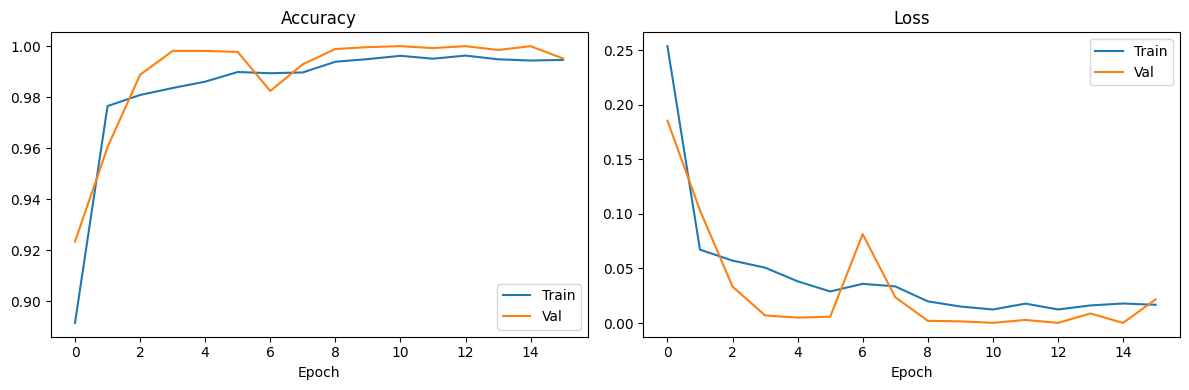

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_accs, label='Train'); axes[0].plot(val_accs, label='Val')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(train_losses, label='Train'); axes[1].plot(val_losses, label='Val')
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].legend()

plt.tight_layout(); plt.show()

## Step 10 — Test set evaluation

In [15]:
model.eval()
all_preds, all_probs, all_labels = [], [], []
with torch.no_grad():
    for images, labels in test_loader:
        probs = torch.sigmoid(model(images.to(device))).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend((probs > 0.5).astype(int))
        all_labels.extend(labels.numpy())

In [16]:
print(f'Accuracy : {accuracy_score(all_labels, all_preds):.4f}')
print(f'Precision: {precision_score(all_labels, all_preds):.4f}')
print(f'Recall   : {recall_score(all_labels, all_preds):.4f}')
print(f'F1 Score : {f1_score(all_labels, all_preds):.4f}')
print(f'ROC AUC  : {roc_auc_score(all_labels, all_probs):.4f}')
print()
print(classification_report(all_labels, all_preds, target_names=['Real', 'Fake']))

Accuracy : 0.9985
Precision: 0.9970
Recall   : 1.0000
F1 Score : 0.9985
ROC AUC  : 1.0000

              precision    recall  f1-score   support

        Real       1.00      1.00      1.00      1338
        Fake       1.00      1.00      1.00      1341

    accuracy                           1.00      2679
   macro avg       1.00      1.00      1.00      2679
weighted avg       1.00      1.00      1.00      2679



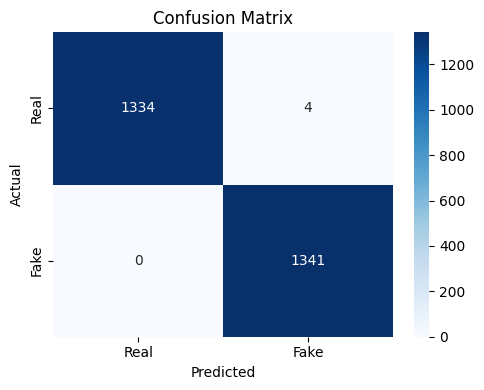

In [17]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.show()

## Step 11 — Save and download model

In [18]:
torch.save(model.state_dict(), '/content/deepfake_audio_detector.pth')
print('Saved.')
files.download('/content/deepfake_audio_detector.pth')

Saved.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>